# EDA complementar: conteúdo informativo geral
Executar todas as células em Python 3.12. Os três anexos permanecem intactos em `originais/`.
Este complemento não reexecuta nem substitui as análises anteriores. Não atribui veracidade às notícias.

Dependências: `python -m pip install -r requirements.txt`. O tokenizer precisa de acesso inicial ao vocabulário, ou do cache em `tokenizer_cache/` distribuído no pacote. Ajuste `CSV` se executar o notebook avulso.

A versão e a origem editorial da base não foram informadas. SHA-256 identifica apenas os bytes analisados.

In [1]:
from pathlib import Path
import os, json, re, hashlib, platform, importlib.metadata as im
from urllib.parse import urlsplit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import tiktoken
ROOT = Path.cwd()
CSV = ROOT / 'originais/Historico_de_materias(1).csv'
if not CSV.exists():
    CSV = next((p for p in [ROOT/'Historico_de_materias.csv', ROOT/'Historico_de_materias(1).csv'] if p.exists()), CSV)
OUT = ROOT
for d in ['figuras', 'tabelas']: (OUT/d).mkdir(exist_ok=True)
if (ROOT/'tokenizer_cache').exists(): os.environ['TIKTOKEN_CACHE_DIR'] = str(ROOT/'tokenizer_cache')
enc = tiktoken.get_encoding('cl100k_base')
df = pd.read_csv(CSV, dtype=str, keep_default_na=False, encoding='utf-8')
N = len(df)
raw = df['conteudo_noticia']
blank = df.apply(lambda s: s.str.strip().eq(''))
sha = hashlib.sha256(CSV.read_bytes()).hexdigest()
versions = {p:im.version(p) for p in ['pandas','numpy','matplotlib','tiktoken','nbformat','nbclient','ipykernel']}
print('Registros:', N, '| Campos:', list(df.columns))
print('SHA-256:', sha, '| Python:', platform.python_version())
print(versions)
assert set(df.columns)=={'data','url_noticia','url_noticia_curto','titulo','conteudo_noticia','assunto'}

Registros: 10109 | Campos: ['data', 'url_noticia', 'url_noticia_curto', 'titulo', 'conteudo_noticia', 'assunto']
SHA-256: a450d9acd272d843d29af1e0b13892386a4fd68525a0d9fd48a41d359aafa24c | Python: 3.12.14
{'pandas': '2.2.3', 'numpy': '2.3.5', 'matplotlib': '3.10.8', 'tiktoken': '0.14.0', 'nbformat': '5.11.1', 'nbclient': '0.11.0', 'ipykernel': '7.4.0'}


## 1. Integridade e denominadores
Leitura UTF-8, separador vírgula, aspas padrão CSV, sem conversão automática de strings como `NA` para nulos. Ausente físico = string de comprimento zero. Vazio adicional = somente espaços/quebras/tabulações. CSV não permite distinguir nulo lógico de string vazia sem um dicionário de dados.

Datas: formato ISO `AAAA-MM-DD` estrito e validade no calendário. URLs: HTTP(S), hostname DNS com pelo menos dois rótulos válidos, porta válida, sem espaços, escapes percentuais inválidos ou credenciais. São verificações sintáticas, sem resolver DNS nem consultar páginas. Duplicatas exatas não são equivalentes a duplicatas semânticas. Para URL e conteúdo, vazios são excluídos. Excesso = repetições depois da primeira; envolvidos = todos os registros em grupos repetidos. Não remover registros automaticamente.

In [2]:
integridade = pd.DataFrame({'campo':df.columns,'ausente_fisico':[int(df[c].eq('').sum()) for c in df],
 'so_espacos':[int((blank[c]&df[c].ne('')).sum()) for c in df],
 'ausente_ou_vazio':[int(blank[c].sum()) for c in df]})
integridade['ausente_ou_vazio_pct']=100*integridade.ausente_ou_vazio/N
integridade['preenchidos']=N-integridade.ausente_ou_vazio
integridade['completude_pct']=100*integridade.preenchidos/N
integridade['denominador']=N
parsed=pd.to_datetime(df.data.where(df.data.str.fullmatch(r'\d{4}-\d{2}-\d{2}')),format='%Y-%m-%d',errors='coerce')
invalid_date=~blank.data & parsed.isna()
def url_ok(v):
    try:
        if re.search(r'\s|%(?![0-9A-Fa-f]{2})',v): return False
        u=urlsplit(v); h=u.hostname
        if u.scheme not in ('http','https') or not h or u.username or u.password: return False
        port=u.port
        labels=h.rstrip('.').encode('idna').decode().split('.')
        return len(labels)>=2 and all(re.fullmatch(r'[A-Za-z0-9](?:[A-Za-z0-9-]{0,61}[A-Za-z0-9])?',x) for x in labels)
    except (ValueError,UnicodeError):return False
badurls={c:~blank[c]&~df[c].map(url_ok) for c in ['url_noticia','url_noticia_curto']}
short=~blank.conteudo_noticia & raw.str.len().lt(100)
issues=[]
def issue(name, mask, eligible):
    k=int(mask.sum()); d=int(eligible.sum())
    issues.append({'criterio':name,'quantidade':k,'denominador_elegivel':d,'pct_elegivel':100*k/d if d else np.nan,'pct_total':100*k/N})
issue('Datas inválidas',invalid_date,~blank.data)
for c,b in badurls.items():issue('URL malformada: '+c,b,~blank[c])
issue('Conteúdo não vazio <100 caracteres',short,~blank.conteudo_noticia)
issue('Conteúdo <100 caracteres incluindo vazios',raw.str.len().lt(100),pd.Series(True,index=df.index))
issues=pd.DataFrame(issues)
dups=[]
for label,cols in [('Linhas (6 campos)',list(df.columns)),('URL principal',['url_noticia']),('URL curta',['url_noticia_curto']),('Conteúdo original',['conteudo_noticia'])]:
    eligible=pd.Series(True,index=df.index) if len(cols)>1 else ~blank[cols[0]]
    sub=df.loc[eligible,cols]; excess=int(sub.duplicated().sum()); involved=int(sub.duplicated(keep=False).sum())
    groups=int(sub[sub.duplicated(keep=False)].drop_duplicates().shape[0])
    dups.append({'criterio':label,'grupos':groups,'excesso':excess,'envolvidos':involved,'denominador':len(sub),'excesso_pct':100*excess/len(sub),'envolvidos_pct':100*involved/len(sub)})
dups=pd.DataFrame(dups)
# Diagnóstico secundário, distinto da igualdade exata: apenas normaliza espaços.
norm=raw.str.replace(r'\s+',' ',regex=True).str.strip()
norm_excess=int(norm[~blank.conteudo_noticia].duplicated().sum())
local_ok=~blank.any(axis=1)&~invalid_date&~pd.concat(badurls,axis=1).any(axis=1)&~short
local_unique=local_ok&~df.duplicated()&~df.url_noticia.duplicated()&~df.url_noticia_curto.duplicated()&~raw.duplicated()
meta=pd.DataFrame({'indicador':['Todos os campos preenchidos','Critérios locais (sem unicidade)','Critérios locais + primeiras ocorrências','Identificador de origem documentado','Emissor verificado documentado'],
 'registros':[int((~blank.any(axis=1)).sum()),int(local_ok.sum()),int(local_unique.sum()),0,0]})
meta['pct']=100*meta.registros/N
meta['meta_numerica_98']=meta.pct>=98
for x in [integridade,issues,dups,meta]:display(x)
print('Excesso de conteúdos após normalizar apenas espaços:',norm_excess)
print('Datas válidas:',parsed.min(),parsed.max())
for c in ['url_noticia','url_noticia_curto']:
 print('Domínios observados, não emissores verificados:',c,df[c].map(lambda u:urlsplit(u).hostname).value_counts().to_dict())
for name,x in [('integridade',integridade),('anomalias',issues),('duplicatas',dups),('meta_98',meta)]:x.to_csv(OUT/'tabelas'/f'{name}.csv',index=False)

,campo,ausente_fisico,so_espacos,ausente_ou_vazio,ausente_ou_vazio_pct,preenchidos,completude_pct,denominador
0,data,0,0,0,0.00000,10109,100.00000,10109
1,url_noticia,0,0,0,0.00000,10109,100.00000,10109
2,url_noticia_curto,0,0,0,0.00000,10109,100.00000,10109
3,titulo,0,0,0,0.00000,10109,100.00000,10109
4,conteudo_noticia,6,3,9,0.08903,10100,99.91097,10109
5,assunto,0,0,0,0.00000,10109,100.00000,10109


,criterio,quantidade,denominador_elegivel,pct_elegivel,pct_total
0,Datas inválidas,4,10109,0.039569,0.039569
1,URL malformada: url_noticia,3,10109,0.029677,0.029677
2,URL malformada: url_noticia_curto,3,10109,0.029677,0.029677
3,Conteúdo não vazio <100 caracteres,5,10100,0.049505,0.049461
4,Conteúdo <100 caracteres incluindo vazios,14,10109,0.138490,0.138490


,criterio,grupos,excesso,envolvidos,denominador,excesso_pct,envolvidos_pct
0,Linhas (6 campos),0,0,0,10109,0.000000,0.000000
1,URL principal,3,3,6,10109,0.029677,0.059353
2,URL curta,19,20,39,10109,0.197844,0.385795
3,Conteúdo original,21,22,43,10100,0.217822,0.425743


,indicador,registros,pct,meta_numerica_98
0,Todos os campos preenchidos,10100,99.910970,True
1,Critérios locais (sem unicidade),10088,99.792264,True
2,Critérios locais + primeiras ocorrências,10067,99.584529,True
3,Identificador de origem documentado,0,0.000000,False
4,Emissor verificado documentado,0,0.000000,False


Excesso de conteúdos após normalizar apenas espaços: 22
Datas válidas: 2014-01-01 00:00:00 2020-04-21 00:00:00
Domínios observados, não emissores verificados: url_noticia {'web.archive.org': 10109}
Domínios observados, não emissores verificados: url_noticia_curto {'globoesporte.globo.com': 4800, 'g1.globo.com': 3538, 'sportv.globo.com': 1230, 'gshow.globo.com': 540, 'redeglobo.globo.com': 1}


## 2. Tokens sobre o original
Tokenizer BPE `cl100k_base`, biblioteca `tiktoken` com versão registrada acima; encoding associado à família GPT-4/GPT-3.5 no mapeamento local da biblioteca. Não é o tokenizer do MiniLM do notebook anterior nem uma escolha de modelo de produção.

`encode(texto, disallowed_special=())`, sem tokens especiais adicionados, limpeza ou truncamento. Estatísticas incluem os registros vazios (zero tokens). Quartis e P95 usam interpolação linear. Uma tabela adicional separa conteúdos não vazios. Idioma: português observado na amostra e descrito no relatório original; identificação automática de idioma em toda a base não executada.

,registros,pct
tema,,
esportes,6035,59.699278
economia,1558,15.412009
politica,1363,13.483035
tecnologia,613,6.063903
famosos,540,5.341775


,n,min,Q1,mediana,Q3,P95,max,media
Geral (inclui vazios),10109.0,0.0,428.00,637.0,993.00,1952.60,9354.0,814.608764
Geral não vazio,10100.0,1.0,428.00,637.5,993.00,1953.05,9354.0,815.333960
economia,1558.0,71.0,462.25,737.0,1188.50,2389.80,8053.0,957.328626
esportes,6035.0,0.0,417.00,606.0,931.00,1821.00,8811.0,770.628003
famosos,540.0,44.0,245.75,423.5,680.25,1260.75,4909.0,534.457407
politica,1363.0,20.0,559.00,805.0,1124.00,2156.70,9354.0,987.829054
tecnologia,613.0,0.0,417.00,598.0,910.00,1674.20,7705.0,746.499184


faixa,0–150,151–200,201–250,251–500,501–1000,1001–2000,2001–5000,>5000
assunto,,,,,,,,
economia,5,22,42,378,589,397,121,4
esportes,66,76,172,1886,2527,1090,210,8
famosos,49,44,47,189,150,54,7,0
politica,9,11,8,218,661,364,79,13
tecnologia,8,11,22,180,258,120,13,1
GERAL,137,164,291,2851,4185,2025,430,26


faixa,0–150,151–200,201–250,251–500,501–1000,1001–2000,2001–5000,>5000
assunto,,,,,,,,
economia,0.320924,1.412067,2.695764,24.261874,37.804878,25.481386,7.766367,0.256739
esportes,1.093621,1.259321,2.850041,31.251036,41.872411,18.061309,3.479702,0.132560
famosos,9.074074,8.148148,8.703704,35.000000,27.777778,10.000000,1.296296,0.000000
politica,0.660308,0.807043,0.586941,15.994131,48.495965,26.705796,5.796038,0.953778
tecnologia,1.305057,1.794454,3.588907,29.363785,42.088091,19.575856,2.120718,0.163132
GERAL,1.355228,1.622317,2.878623,28.202592,41.398754,20.031655,4.253635,0.257197


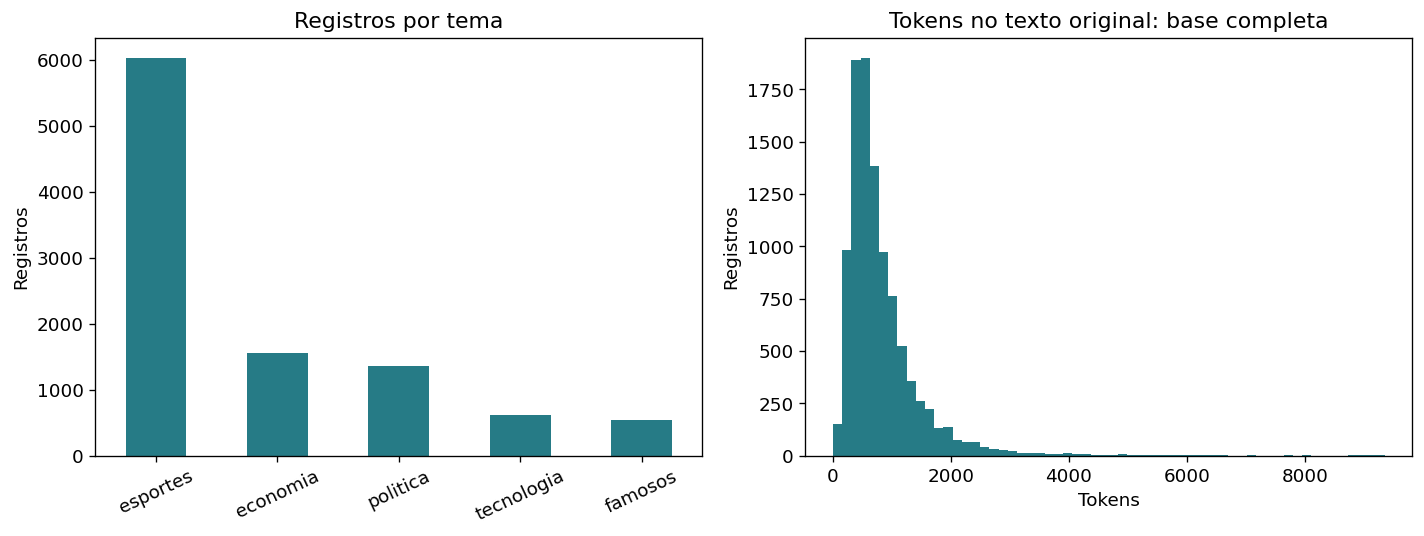

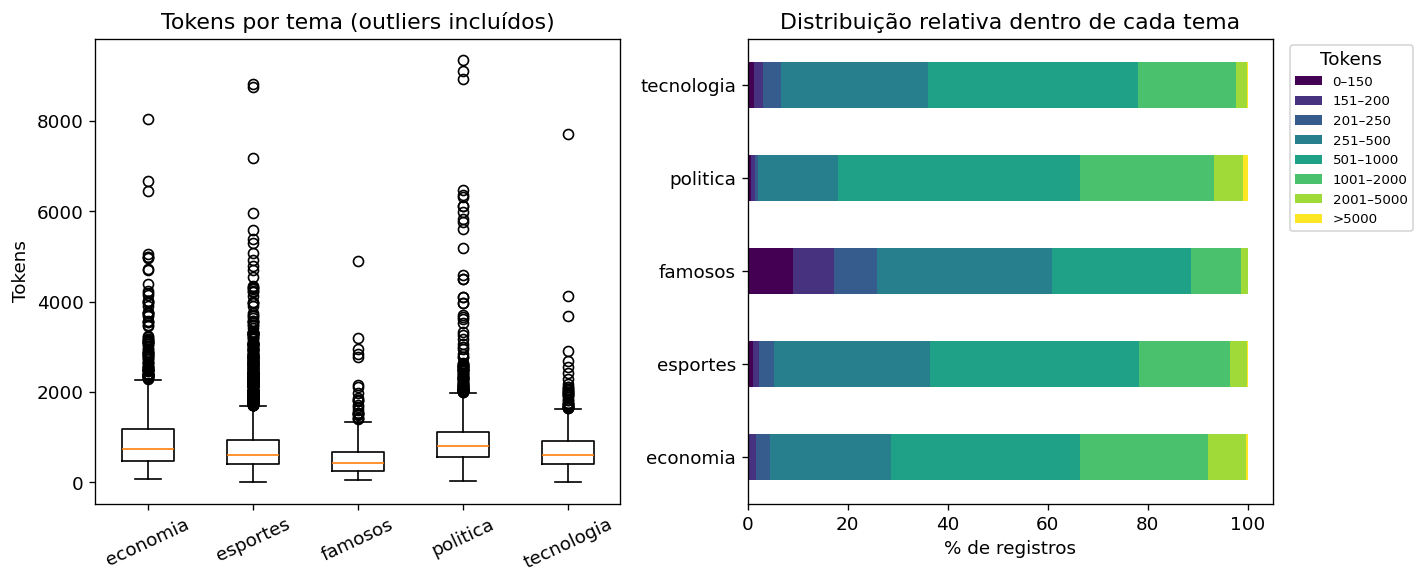

In [3]:
tokens=[enc.encode(s,disallowed_special=()) for s in raw]
df_metrics=pd.DataFrame({'registro_posicional':np.arange(1,N+1),'assunto':df.assunto,'caracteres':raw.str.len(),'tokens':[len(t) for t in tokens]})
def stats(s):
 return pd.Series({'n':len(s),'min':s.min(),'Q1':s.quantile(.25),'mediana':s.median(),'Q3':s.quantile(.75),'P95':s.quantile(.95),'max':s.max(),'media':s.mean()})
token_stats=pd.DataFrame({k:stats(v) for k,v in [('Geral (inclui vazios)',df_metrics.tokens),('Geral não vazio',df_metrics.loc[~blank.conteudo_noticia,'tokens'])]+[(k,g.tokens) for k,g in df_metrics.groupby('assunto')]}).T
counts=df.assunto.value_counts().rename_axis('tema').to_frame('registros');counts['pct']=100*counts.registros/N
bins=[0,150,200,250,500,1000,2000,5000,float('inf')]
labels=['0–150','151–200','201–250','251–500','501–1000','1001–2000','2001–5000','>5000']
df_metrics['faixa']=pd.cut(df_metrics.tokens,bins=bins,labels=labels,include_lowest=True)
dist=pd.crosstab(df_metrics.assunto,df_metrics.faixa,dropna=False).reindex(columns=labels,fill_value=0)
dist.loc['GERAL']=dist.sum();dist_pct=dist.div(dist.sum(axis=1),axis=0)*100
for x in [counts,token_stats,dist,dist_pct]:display(x)
for name,x in [('temas',counts),('tokens_estatisticas',token_stats),('tokens_distribuicao',dist),('tokens_distribuicao_pct',dist_pct)]:x.to_csv(OUT/'tabelas'/f'{name}.csv')
df_metrics.to_csv(OUT/'tabelas/metricas_por_registro.csv',index=False)
plt.rcParams.update({'font.size':11,'figure.dpi':120})
fig,ax=plt.subplots(1,2,figsize=(12,4.6));counts.registros.plot.bar(ax=ax[0],color='#267b86');ax[0].set(title='Registros por tema',ylabel='Registros',xlabel='');ax[0].tick_params(axis='x',rotation=25)
ax[1].hist(df_metrics.tokens,bins=60,color='#267b86');ax[1].set(title='Tokens no texto original: base completa',xlabel='Tokens',ylabel='Registros');fig.tight_layout();fig.savefig(OUT/'figuras/perfil.png');display(fig);plt.close(fig)
fig,ax=plt.subplots(1,2,figsize=(12,5)); groups=list(df_metrics.groupby('assunto'));ax[0].boxplot([g.tokens for _,g in groups],tick_labels=[k for k,_ in groups],showfliers=True);ax[0].tick_params(axis='x',rotation=25);ax[0].set(title='Tokens por tema (outliers incluídos)',ylabel='Tokens')
dist_pct.drop(index='GERAL').plot.barh(stacked=True,ax=ax[1],colormap='viridis');ax[1].set(title='Distribuição relativa dentro de cada tema',xlabel='% de registros',ylabel='');ax[1].legend(title='Tokens',bbox_to_anchor=(1.02,1),loc='upper left',fontsize=8);fig.tight_layout();fig.savefig(OUT/'figuras/tokens_temas.png');display(fig);plt.close(fig)

## 3. Segmentação experimental
Janelas de **até** 150, 200 e 250 tokens, sobreposição **exata de 30 tokens da sequência original**. Uma janela pode ser menor para não cortar UTF-8 e preferir fim de frase ou limite de palavra nos últimos 40 tokens. Não se remove pontuação, negação, caixa ou espaços. A tokenização isolada de um bloco pode diferir da fatia da sequência original por contexto BPE; as duas medidas são registradas.

O algoritmo tenta fim de frase (heurística `[.!?]`), depois limites de palavra, depois limites UTF-8 seguros. Sobreposição fixa não garante frases completas nem correferência resolvida. Título, URL, tema, posição e ligação aos blocos vizinhos ficam recuperáveis pelo registro posicional e tabela de offsets. Esse número é um localizador deste arquivo, não um identificador de origem. Blocos finais podem ser curtos. Conteúdos vazios não geram blocos. Nenhuma recuperação de evidências é testada aqui.

,n,min,Q1,mediana,Q3,P95,max,media,blocos_por_documento,tokens_com_repeticao,fator_expansao,max_tokens_isolados,isolados_acima_limite
limite,,,,,,,,,,,,,
150,76897.0,1.0,125.0,141.0,148.0,150.0,150.0,133.149317,7.613564,10238783,1.243343,150,0
200,54303.0,1.0,171.0,189.0,198.0,200.0,200.0,176.066939,5.376535,9560963,1.161032,200,0
250,42519.0,1.0,217.0,237.0,248.0,250.0,250.0,216.548908,4.209802,9207443,1.118103,250,0


tipo_corte,fim_documento,frase,palavra,utf8
limite,,,,
150,10100,40646,26140,11
200,10100,26755,17442,6
250,10100,19667,12746,6


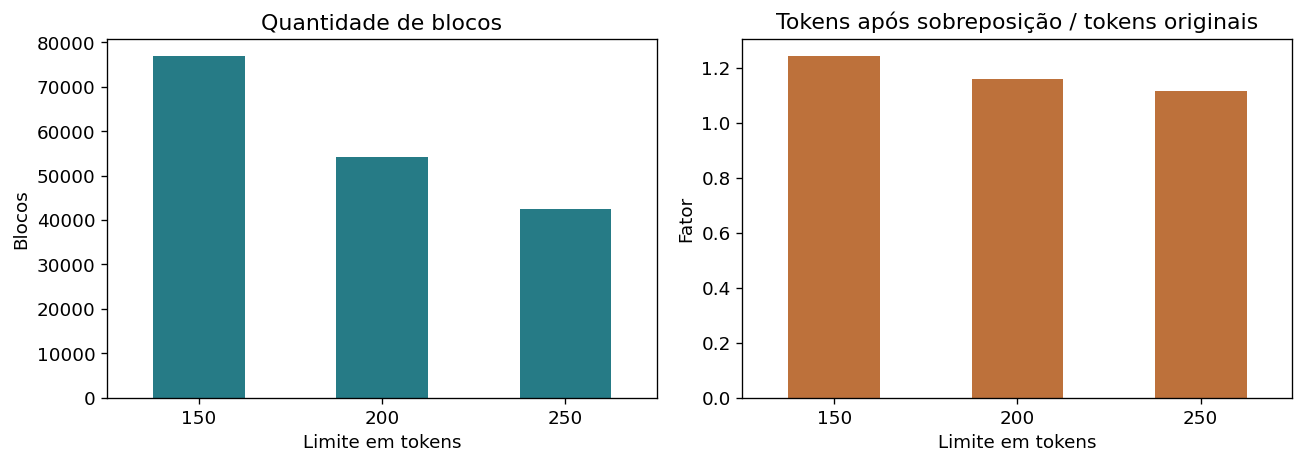

Amostra intencional, registros posicionais 1-based: [929, 2219, 4198, 4348, 4573, 6017, 6120, 6599, 7589, 8801]
Verificados: reconstrução byte a byte de cada texto, limites das janelas e overlap exato de 30 tokens.


In [4]:
from bisect import bisect_left
chunk_rows=[]
sample_ids=[]
# Amostra intencional: texto próximo da mediana e maior texto de cada tema.
for tema,g in df_metrics.groupby('assunto'):
    usable=g[g.tokens>250]
    sample_ids.extend([int((usable.tokens-usable.tokens.median()).abs().idxmin()),int(usable.tokens.idxmax())])
sample_ids=sorted(set(sample_ids))
examples=[]
for idx,(s,ts) in enumerate(zip(raw,tokens)):
 if blank.conteudo_noticia.iloc[idx]:continue
 pieces=[enc.decode_single_token_bytes(t) for t in ts]
 offsets=np.cumsum([0]+[len(p) for p in pieces]).tolist(); b=s.encode('utf-8'); nt=len(ts)
 assert b''.join(pieces)==b
 safe={i for i,o in enumerate(offsets) if o==len(b) or b[o]&0xC0!=0x80}
 def word_boundary(i):
  o=offsets[i]
  return o==0 or o==len(b) or b[:o].decode('utf-8')[-1:].isspace() or b[o:].decode('utf-8')[:1].isspace()
 for size in [150,200,250]:
  start=0;j=0;prev_end=None;reconstructed=b''
  while start<nt:
   cap=min(start+size,nt)
   if cap==nt:end=nt;kind='fim_documento'
   else:
    candidates=[e for e in range(cap,max(start+30,cap-40),-1) if e in safe and e-30 in safe]
    if not candidates:candidates=[e for e in range(cap,start+30,-1) if e in safe and e-30 in safe]
    assert candidates
    sentence=[e for e in candidates if re.search(r'[.!?]\s*$',b[:offsets[e]].decode('utf-8')) and word_boundary(e-30)]
    words=[e for e in candidates if word_boundary(e) and word_boundary(e-30)]
    end=(sentence or words or candidates)[0];kind='frase' if sentence else 'palavra' if words else 'utf8'
   chunk=b[offsets[start]:offsets[end]].decode('utf-8'); isolated=len(enc.encode(chunk,disallowed_special=()))
   if prev_end is not None:assert prev_end-start==30
   reconstructed+=b[offsets[start if prev_end is None else prev_end]:offsets[end]]
   row={'registro_posicional':idx+1,'tema':df.assunto.iloc[idx],'limite':size,'bloco':j+1,'inicio_token':start,'fim_token_exclusivo':end,'inicio_byte':offsets[start],'fim_byte_exclusivo':offsets[end],'tokens_sequencia':end-start,'tokens_isolados':isolated,'sobreposicao':0 if prev_end is None else prev_end-start,'tipo_corte':kind}
   chunk_rows.append(row)
   if idx in sample_ids and j<2:examples.append(dict(row,texto=chunk,titulo=df.titulo.iloc[idx]))
   j+=1;prev_end=end
   if end==nt:break
   start=end-30
  assert reconstructed==b
chunks=pd.DataFrame(chunk_rows)
chunk_stats=chunks.groupby('limite').tokens_sequencia.apply(lambda s:stats(s)).unstack()
chunk_stats['blocos_por_documento']=chunks.groupby('limite').size()/int((~blank.conteudo_noticia).sum())
chunk_stats['tokens_com_repeticao']=chunks.groupby('limite').tokens_sequencia.sum()
chunk_stats['fator_expansao']=chunk_stats.tokens_com_repeticao/sum(map(len,tokens))
chunk_stats['max_tokens_isolados']=chunks.groupby('limite').tokens_isolados.max()
chunk_stats['isolados_acima_limite']=[int(((chunks.limite==k)&(chunks.tokens_isolados>k)).sum()) for k in chunk_stats.index]
cut_types=pd.crosstab(chunks.limite,chunks.tipo_corte)
chunks.to_csv(OUT/'tabelas/blocos_offsets.csv',index=False)
chunk_stats.to_csv(OUT/'tabelas/blocos_estatisticas.csv');cut_types.to_csv(OUT/'tabelas/blocos_tipos_corte.csv')
(OUT/'amostra_cortes.json').write_text(json.dumps(examples,ensure_ascii=False,indent=2),encoding='utf-8')
display(chunk_stats);display(cut_types)
print('Amostra intencional, registros posicionais 1-based:',[i+1 for i in sample_ids])
print('Verificados: reconstrução byte a byte de cada texto, limites das janelas e overlap exato de 30 tokens.')
fig,ax=plt.subplots(1,2,figsize=(11,4));chunk_stats['n'].plot.bar(ax=ax[0],color='#267b86',rot=0);ax[0].set(title='Quantidade de blocos',xlabel='Limite em tokens',ylabel='Blocos');chunk_stats['fator_expansao'].plot.bar(ax=ax[1],color='#bd713b',rot=0);ax[1].set(title='Tokens após sobreposição / tokens originais',xlabel='Limite em tokens',ylabel='Fator');fig.tight_layout();fig.savefig(OUT/'figuras/segmentacao.png');display(fig);plt.close(fig)

## 4. Exportação e limites da avaliação
A leitura qualitativa dos exemplos fica documentada no relatório complementar e em `revisao_amostra.md`. A amostra intencional cobre extensões típicas e extremas dos cinco temas, sem pretensão de representatividade estatística.

**Código existente, não reexecutado:** limpeza, características, n-gramas, outliers, vocabulário, spaCy, embeddings MiniLM, t-SNE e BERTopic. Saídas antigas e contadores de execução não comprovam execução atual.

**Executado neste complemento:** inventário, integridade, estatísticas completas de tokens, gráficos, três segmentações e verificações de reconstrução/sobreposição. A revisão qualitativa é separada dessas verificações automáticas.

**Pendente da implementação:** busca vetorial, NLI, abstenção, pontuação, tempo do fluxo completo, seleção do modelo final, avaliação rotulada e revisão humana de domínio. Não há classificação de verdadeiro/falso. A meta de 98% não tem conformidade global demonstrada: faltam identificador de origem e emissor verificado, além de um contrato formal dos campos/qualidade exigidos.

In [5]:
summary={'registros':N,'csv_sha256':sha,'python':platform.python_version(),'versions':versions,'tokenizer':'cl100k_base','total_tokens':sum(map(len,tokens)),'datas_validas_min':str(parsed.min().date()),'datas_validas_max':str(parsed.max().date()),'conteudo_normalizado_excesso':norm_excess,'amostra_ids':[i+1 for i in sample_ids],'origem':'não informado','versao_base':'não informado','criterios_historicos_escolha':'não informado'}
(OUT/'resumo_execucao.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2),encoding='utf-8')
print(json.dumps(summary,ensure_ascii=False,indent=2))

{
  "registros": 10109,
  "csv_sha256": "a450d9acd272d843d29af1e0b13892386a4fd68525a0d9fd48a41d359aafa24c",
  "python": "3.12.14",
  "versions": {
    "pandas": "2.2.3",
    "numpy": "2.3.5",
    "matplotlib": "3.10.8",
    "tiktoken": "0.14.0",
    "nbformat": "5.11.1",
    "nbclient": "0.11.0",
    "ipykernel": "7.4.0"
  },
  "tokenizer": "cl100k_base",
  "total_tokens": 8234880,
  "datas_validas_min": "2014-01-01",
  "datas_validas_max": "2020-04-21",
  "conteudo_normalizado_excesso": 22,
  "amostra_ids": [
    929,
    2219,
    4198,
    4348,
    4573,
    6017,
    6120,
    6599,
    7589,
    8801
  ],
  "origem": "não informado",
  "versao_base": "não informado",
  "criterios_historicos_escolha": "não informado"
}


## 5. Complemento: marcadores de ausência
Os quatro valores `NA` em data são candidatos a ausência. A interpretação oficial não foi informada. O teste de datas também os sinaliza; não somar duas vezes.

In [6]:
# Diagnóstico de marcadores textuais e localização das ocorrências.
markers = df.apply(lambda s:s.str.strip().str.lower().isin(['na','n/a','null','none','nan']))
sentinel = pd.DataFrame({'campo':df.columns,'marcadores_potenciais':markers.sum().values})
sentinel['marcadores_pct'] = 100*sentinel.marcadores_potenciais/N
sentinel['ausente_vazio_ou_marcador'] = (blank|markers).sum().values
sentinel['completude_sem_marcadores_pct'] = 100*(N-sentinel.ausente_vazio_ou_marcador)/N
sentinel.to_csv(OUT/'tabelas/marcadores_ausencia.csv',index=False)
display(sentinel)
flags=pd.DataFrame({'conteudo_vazio':blank.conteudo_noticia,'data_invalida':invalid_date,
 'url_principal_malformada':badurls['url_noticia'],'url_curta_malformada':badurls['url_noticia_curto'],'texto_curto_nao_vazio':short})
audit=pd.concat([pd.Series(np.arange(1,N+1),name='registro_posicional'),df[['data','titulo','url_noticia','url_noticia_curto']],flags],axis=1)
audit.loc[flags.any(axis=1)].to_csv(OUT/'tabelas/ocorrencias_integridade.csv',index=False)
print('Registros com pelo menos uma ocorrência local:',int(flags.any(axis=1).sum()))
print('URLs malformadas:',list(np.where(badurls['url_noticia'])[0]+1),list(np.where(badurls['url_noticia_curto'])[0]+1))


,campo,marcadores_potenciais,marcadores_pct,ausente_vazio_ou_marcador,completude_sem_marcadores_pct
0,data,4,0.039569,4,99.960431
1,url_noticia,0,0.000000,0,100.000000
2,url_noticia_curto,0,0.000000,0,100.000000
3,titulo,0,0.000000,0,100.000000
4,conteudo_noticia,0,0.000000,9,99.910970
5,assunto,0,0.000000,0,100.000000


Registros com pelo menos uma ocorrência local: 21
URLs malformadas: [np.int64(3829), np.int64(3833), np.int64(8029)] [np.int64(3829), np.int64(3833), np.int64(8029)]


## 6. Revisão qualitativa registrada

### Observações por documento revisado

| registro | tema | observacao |
| --- | --- | --- |
| 929 | esportes | 150 interrompe a hipótese de grito ao telefone; 200 e 250 encerram frases. A negação “não se encaixava” permanece no bloco 2 e no overlap de 200. |
| 2219 | economia | Os três cortes terminam frases. O início do bloco seguinte retoma apenas parte de uma enumeração ou condição tarifária; consultar o anterior preserva o alcance. |
| 4198 | esportes | 200 corta “carimbar a passagem” após “a”. 250 mantém a frase com “não foi marcante apenas”; essa negação não pode ser removida. |
| 4348 | politica | 150 corta a explicação da disputa; 250 separa o nome “Alexandre de Moraes”. O overlap recupera o contexto, mas o primeiro bloco isolado fica incompleto. |
| 4573 | economia | 150 e 250 fecham frases; 200 interrompe a percepção otimista antes do complemento sobre reformas. Valores monetários e pontuação permanecem intactos. |
| 6017 | famosos | 150 mantém a troca de músicas e o título “Não Ter”; 200 e 250 interrompem informações de agenda. Chamadas editoriais com “+” permanecem, pois já estão na base. |
| 6120 | famosos | Os três primeiros cortes fecham frases; “não seria”, “Quando não prepara” e a citação “Não gosto” permanecem. O segundo bloco pode depender do sujeito apresentado antes. |
| 6599 | tecnologia | Há pergunta e resposta, mudança de assunto e um salto de “passos descritos abaixo” para “Pronto!” já no original. O chunker não recupera instruções ausentes da extração. |
| 7589 | tecnologia | 150 corta a localização do salão e 200 corta “Nada mau para um negócio”. 250 encerra a frase; o bloco 2 mantém “Não foi” e “Nem uma mudança”. |
| 8801 | politica | Os primeiros blocos descrevem a identidade alegada; a ressalva “nunca existiu” aparece no segundo bloco de 200/250. Byte preservation não garante evidência suficiente em um bloco isolado. |

### Registro dos 30 cortes revisados

| registro | limite | tokens_A | tokens_B | fim_A_token | inicio_B_token | tipo |
| --- | --- | --- | --- | --- | --- | --- |
| 929 | 150 | 150 | 139 | 150 | 120 | palavra |
| 929 | 200 | 193 | 200 | 193 | 163 | frase |
| 929 | 250 | 235 | 250 | 235 | 205 | frase |
| 2219 | 150 | 141 | 124 | 141 | 111 | frase |
| 2219 | 200 | 175 | 199 | 175 | 145 | frase |
| 2219 | 250 | 235 | 247 | 235 | 205 | frase |
| 4198 | 150 | 130 | 126 | 130 | 100 | frase |
| 4198 | 200 | 200 | 200 | 200 | 170 | palavra |
| 4198 | 250 | 226 | 246 | 226 | 196 | frase |
| 4348 | 150 | 145 | 150 | 145 | 115 | palavra |
| 4348 | 200 | 196 | 199 | 196 | 166 | frase |
| 4348 | 250 | 247 | 221 | 247 | 217 | palavra |
| 4573 | 150 | 116 | 130 | 116 | 86 | frase |
| 4573 | 200 | 199 | 186 | 199 | 169 | palavra |
| 4573 | 250 | 216 | 229 | 216 | 186 | frase |
| 6017 | 150 | 116 | 124 | 116 | 86 | frase |
| 6017 | 200 | 199 | 198 | 199 | 169 | palavra |
| 6017 | 250 | 250 | 247 | 250 | 220 | palavra |
| 6120 | 150 | 135 | 112 | 135 | 105 | frase |
| 6120 | 200 | 161 | 199 | 161 | 131 | frase |
| 6120 | 250 | 217 | 249 | 217 | 187 | frase |
| 6599 | 150 | 145 | 119 | 145 | 115 | frase |
| 6599 | 200 | 169 | 161 | 169 | 139 | frase |
| 6599 | 250 | 234 | 242 | 234 | 204 | frase |
| 7589 | 150 | 145 | 141 | 145 | 115 | palavra |
| 7589 | 200 | 197 | 190 | 197 | 167 | palavra |
| 7589 | 250 | 239 | 250 | 239 | 209 | frase |
| 8801 | 150 | 148 | 120 | 148 | 118 | frase |
| 8801 | 200 | 175 | 168 | 175 | 145 | frase |
| 8801 | 250 | 238 | 233 | 238 | 208 | frase |

A diferença entre fim_A_token (exclusivo) e inicio_B_token é 30 em todas as linhas. Índices de tokens iniciam em zero.

### Exemplos literais de fronteiras

Os trechos abaixo mostram o fim do bloco A e o início do B. São recortes de exibição; o JSON contém os blocos completos.

**Registro 929, limite 200.**

Final do bloco A:

```text
utador achou que fosse apenas alguém gritando no telefone celular, mas viu, à distância, que a linguagem corporal da pessoa não se encaixava com a de alguém que estivesse apenas brigando numa ligação.
```

Início do bloco B:

```text
 a linguagem corporal da pessoa não se encaixava com a de alguém que estivesse apenas brigando numa ligação. Weidman dirigiu seu carro pela rua até encontrar a mulher pedindo socorro na entrada de sua casa.
	- Ela estava completamente ensanguentada, era uma cena de pesadelo. Havia sangue saindo de s
```

**Registro 4348, limite 250.**

Final do bloco A:

```text
s de 120 pessoas.  "Em reunião na manhã desta quarta-feira (18) com representantes da Federação Sindical Nacional dos Servidores Penitenciários (Fenaspen), o ministro da Justiça e Cidadania, Alexandre
```

Início do bloco B:

```text
 Federação Sindical Nacional dos Servidores Penitenciários (Fenaspen), o ministro da Justiça e Cidadania, Alexandre de Moraes, anunciou a criação de um Grupo Nacional de Intervenção Penitenciária, que atuará dentro dos presídios em conjunto com os estados", diz a nota do ministério.  Ainda segundo a
```

**Registro 7589, limite 200.**

Final do bloco A:

```text
tinha um pequeno salão próximo ao metrô São Judas, também na zona sul da capital, chegou a despachar 90 entregas por dia, metade da sua demanda diária, com uma média de R$ 55 por pedido. Nada mau para
```

Início do bloco B:

```text
 entregas por dia, metade da sua demanda diária, com uma média de R$ 55 por pedido. Nada mau para um negócio de pequeno porte.  Mas, no começo de 2019, algo começou a dar errado: os pedidos deixaram de aparecer de uma hora para outra. Não foi uma redução gradual, fruto de um possível aumento de comp
```

**Registro 8801, limite 250.**

Final do bloco A:

```text
es surgiram, quase que 'por mágica', os mais variados e-mails falsos que caluniam Dilma Rousseff. Venho aqui neste blog, sempre que possível, desmentindo um por um", escreveu em uma de suas postagens.
```

Início do bloco B:

```text
 Rousseff. Venho aqui neste blog, sempre que possível, desmentindo um por um", escreveu em uma de suas postagens.  Esse "Armando", no entanto, nunca existiu. Seu blog e seus perfis no Orkut e no Twitter eram administrados por quatro pessoas que teriam recebido, para tanto, de R$ 3,5 mil a R$ 4 mil m
```

Os cortes em palavras não eliminam bytes, mas deixam frases incompletas. A sobreposição reduz esse problema sem resolvê-lo em todos os casos. Em particular, a ressalva do registro 8801 demonstra por que não se deve inferir veracidade a partir de um trecho isolado.


**Execução nesta entrega:** células executadas sequencialmente em um processo Python com captura de saídas. Inicialização de kernel Jupyter bloqueada por restrição de sockets. Reprodução com kernel Jupyter/Colab externo não verificada.